# **EDA: exploración y procesamiento de imágenes**

## **Librerías necesarias**

In [1]:
import os
import cv2
import tiff
import json
import shutil
import imageio
import warnings
import nbimporter
import pandas as pd
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
from funciones import *
warnings.filterwarnings("ignore")


In [2]:
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'Bahnschrift'
color_morado = '#9370DB'
colores_morado = ['#9370DB', '#8A2BE2']
ruta_imagenes = "C:/Users/kamac/OneDrive/Desktop/Parcial1_DeepLearning/data/train_filter/"
imagen_pruebas = "00ca2f4c8918"
imagen_pruebas2 = "912ebd02ee50"

## **Contextualización de los datos**

Los datos incluyen imágenes histológicas de riñón humano en formato **WSI**, de las cuales se han extraído pequeños mosaicos llamados **teselas**.  

El objetivo es **identificar y segmentar estructuras de microvasculatura (vasos sanguíneos)** en estas imágenes. Para esto, los datos se dividen en tres conjuntos principales con diferentes niveles de anotación:  
- **Conjunto de Datos 1:** Teselas con anotaciones revisadas por expertos.  
- **Conjunto de Datos 2:** Teselas con anotaciones dispersas, pero sin revisión experta.  
- **Conjunto de Datos 3:** Teselas de WSI adicionales **sin anotaciones** (En este proyecto no se usará este conjunto de datos ya que es ideal para posibles técnicas de aprendizaje semisupervisado o autosupervisado y nuestro enfoque es en modelos de aprendizaje supervisado).  

`````{admonition} ¿Qué es una WSI y qué son las teselas? 
:class: tip
Las WSI (Whole Slide Images) son imágenes digitales de alta resolución obtenidas de muestras de tejido en un portaobjetos de microscopio. Debido a su gran tamaño, estas imágenes se dividen en pequeñas secciones llamadas teselas, que son imágenes más manejables de 512x512 píxeles. Las teselas permiten analizar regiones específicas del tejido sin necesidad de procesar la WSI completa. 
`````

### **Archivos y estructura de datos**  

#### **Carpetas principales:**  
- **train:** Contiene las imágenes TIFF de los mosaicos de entrenamiento (tamaño 512x512 píxeles).  

#### **Archivos clave:**  
- **polygons.jsonl** (Máscaras de segmentación poligonal)  
    - Este archivo contiene las anotaciones de segmentación en formato **JSONL** (JSON Lines, es decir, un JSON por línea).  
    - Cada línea corresponde a una imagen y contiene:  
      - `id`: Identificador de la imagen.  
      - `annotations`: Lista de anotaciones de estructuras con:  
        - `type`: Tipo de estructura segmentada:  
          - `blood_vessel` (vaso sanguíneo, el objetivo principal).  
          - `glomerulus` (glomerulo, una estructura que **no debe** incluirse en las predicciones, ya que se considerará un error).  
          - `unsure` (estructuras que los anotadores no pudieron clasificar con certeza).  
        - `coordinates`: Lista de coordenadas poligonales que definen la máscara de segmentación.  
- **tile_meta.csv** (Metadatos de cada tesela)  
    - Contiene información sobre cada mosaico, incluyendo:  
      - `source_wsi`: De qué WSI proviene.  
      - `{i, j}`: Ubicación dentro de la WSI de donde se extrajo.  
      - `dataset`: A qué conjunto de datos pertenece (1, 2 o 3).  
- **wsi_meta.csv** (Metadatos de las imágenes WSI completas)  
    - Contiene información demográfica del donante del tejido:  
      - `age`, `sex`, `race`, `height`, `weight`, `bmi`.  



`````{admonition} ¿Qué es una imagen TIFF?
:class: tip
TIFF (Tagged Image File Format) es un formato de imagen de alta calidad y sin pérdida de datos. Se utiliza comúnmente en microscopía, impresión y almacenamiento de imágenes médicas y científicas.
`````


> Los datos utilizados en este trabajo provienen de la competencia **HuBMAP - Hacking the Human Vasculature** {cite}`hubmap-hacking-the-human-vasculature`, disponibles en Kaggle.

## **wsi_meta: Datos demográficos de los donantes de tejidos**

En este estudio participaron únicamente cuatro pacientes, a quienes se les tomaron muestras de tejido en portaobjetos de microscopio. La cantidad limitada de participantes se debió al uso de imágenes WSI de alta resolución. Estas imágenes, debido a su gran tamaño, tuvieron que ser divididas en pequeñas secciones llamadas teselas. Este proceso de división fue necesario para manejar adecuadamente los datos, pero también representó una limitación en el número de pacientes que se pudo incluir en el estudio. Veamos un poco sobre estos pacientes.

In [3]:
data_donantes = pd.read_csv('wsi_meta.csv')
data_donantes

,source_wsi,age,sex,race,height,weight,bmi
0,1,58,F,W,160.0,59.0,23.0
1,2,56,F,W,175.2,139.6,45.5
2,3,73,F,W,162.3,87.5,33.2
3,4,53,M,B,166.0,73.0,26.5


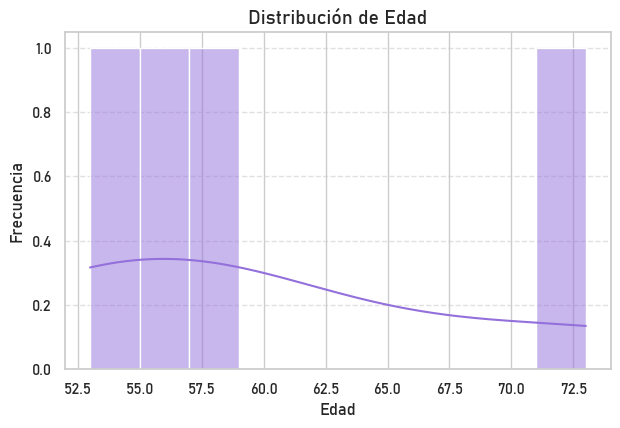

In [4]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(data_donantes['age'], bins = 10, kde = True, color = color_morado)
plt.title('Distribución de Edad', fontsize = 14)
plt.xlabel('Edad', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.grid(axis='y', linestyle='--', alpha = 0.6)
plt.tight_layout()
plt.show()

Al observar la gráfica notamos que no existe una distribución clara en la figura dado la cantidad de pacientes a las que se le realizó el estudio y cada uno de estos pacientes tiene una edad diferente.

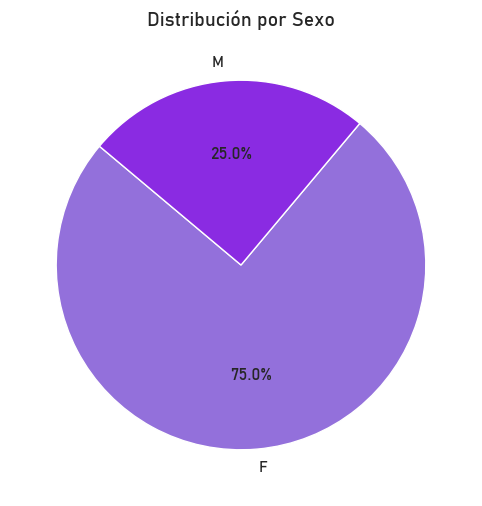

In [5]:
plt.figure(figsize = (10, 6))
sex_counts = data_donantes['sex'].value_counts()
plt.pie(sex_counts, labels=sex_counts.index, autopct = '%1.1f%%', startangle = 140, colors = colores_morado)
plt.title('Distribución por Sexo', fontsize = 14)
plt.show()

De lo anterior podemos concluir que el sexo que predomina entre los pacientes muestreados es **femenino**, lo que corresponde aproximadamente a **3** mujeres.

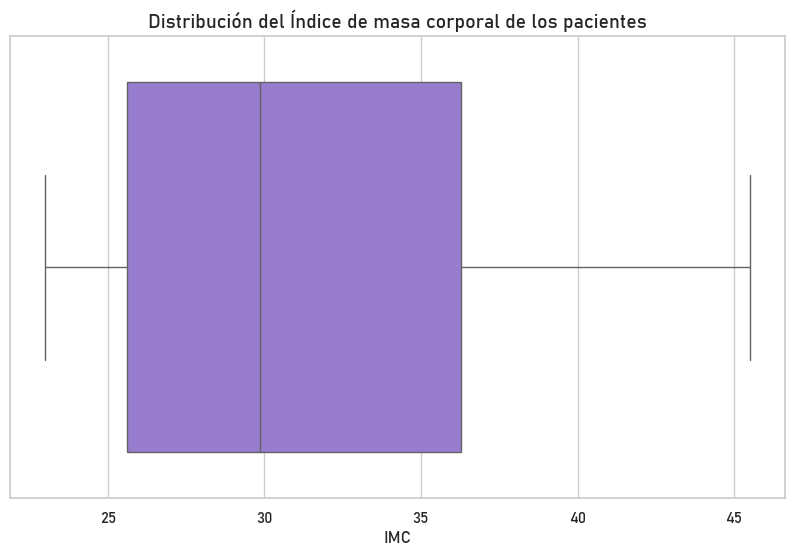

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='bmi', data = data_donantes, color = color_morado)
plt.title('Distribución del Índice de masa corporal de los pacientes', fontsize = 14)
plt.xlabel('IMC', fontsize = 12)
plt.show()

El boxplot muestra la distribución del IMC de cuatro pacientes, con valores entre aproximadamente 23 y 45. La mediana se encuentra alrededor de 30-32, lo que indica que dos pacientes tienen un IMC inferior y dos superior a este valor. La caja abarca el rango intercuartílico (~27-35), sugiriendo que la mitad de los valores están en este intervalo. Los bigotes alcanzan los extremos sin valores atípicos visibles, reflejando una distribución sin datos fuera del rango esperado. En general, la mayoría de los pacientes presentan sobrepeso u obesidad, ya que el IMC se encuentra mayormente por encima de 25, lo que podría implicar riesgos para la salud asociados a estas condiciones.

## **tile_meta: Datos sobre las teselas**

En el siguiente conjunto de datos, se presenta información detallada sobre las muestras divididas en teselas.

In [7]:
data_info_teselas = pd.read_csv('tile_meta.csv')
data_info_teselas.head()

,id,source_wsi,dataset,i,j
0,0006ff2aa7cd,2,2,16896,16420
1,000e79e206b7,6,3,10240,29184
2,00168d1b7522,2,2,14848,14884
3,00176a88fdb0,7,3,14848,25088
4,0033bbc76b6b,1,1,10240,43008


In [8]:
data_info_teselas.shape

(7033, 5)

El conjunto de datos consta de **7033** observaciones, es decir, 7033 teselas. Dado que se decidió no trabajar con el conjunto de datos 3, filtraremos el conjunto para incluir únicamente los datos pertenecientes a los conjuntos 1 y 2.

In [9]:
data_imagenes_teselas = data_info_teselas[data_info_teselas['dataset'].isin([1, 2])]

In [10]:
data_imagenes_teselas.shape

(1633, 5)

Ahora solo contamos con 1633 imágenes, que son las de interés en este trabajo. Veamos algunas gráficas para estos datos.

Guardemos las imágenes filtradas en una nueva carpeta 

In [11]:
def copiar_imagenes_a_nueva_carpeta(df, columna_id, ruta_origen, ruta_destino):

    # Crear la carpeta destino si no existe
    if not os.path.exists(ruta_destino):
        os.makedirs(ruta_destino)

    # Iterar sobre los IDs y copiar las imágenes
    for img_id in df[columna_id]:
        nombre_archivo = f"{img_id}.tif"  # Suponiendo que los archivos tienen extensión .tif
        ruta_original = os.path.join(ruta_origen, nombre_archivo)
        ruta_copia = os.path.join(ruta_destino, nombre_archivo)
        os.path.exists(ruta_original)
        shutil.copy(ruta_original, ruta_copia)  # Copiar la imagen
    


data_imagenes_teselas = data_info_teselas[data_info_teselas['dataset'].isin([1, 2])]

ruta_imagenes = "C:/Users/kamac/OneDrive/Desktop/Parcial1_DeepLearning/data/train/" 
ruta_destino = "C:/Users/kamac/OneDrive/Desktop/Parcial1_DeepLearning/data/train_filter/" 

copiar_imagenes_a_nueva_carpeta(data_imagenes_teselas, "id", ruta_imagenes, ruta_destino)


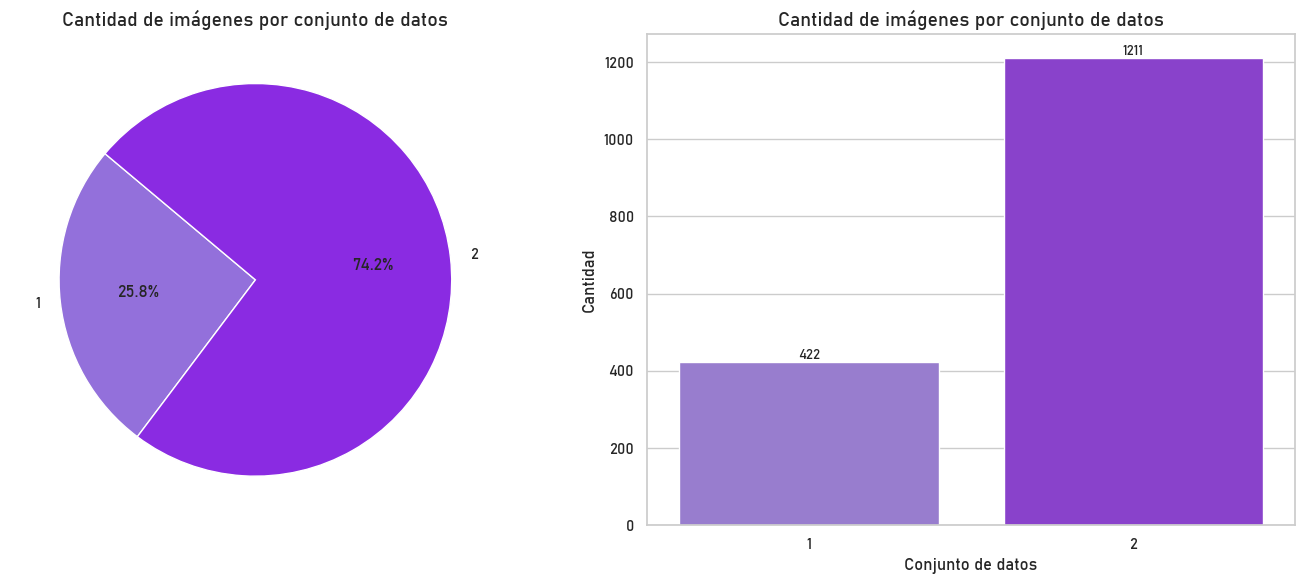

In [12]:
dataset_counts = data_imagenes_teselas['dataset'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(dataset_counts, labels=dataset_counts.index, autopct='%1.1f%%', startangle=140, colors=colores_morado)
axes[0].set_title('Cantidad de imágenes por conjunto de datos', fontsize=14)
sns.barplot(x=dataset_counts.index, y=dataset_counts.values, ax=axes[1], palette=colores_morado)
axes[1].set_title('Cantidad de imágenes por conjunto de datos', fontsize=14)
axes[1].set_xlabel('Conjunto de datos', fontsize=12)
axes[1].set_ylabel('Cantidad', fontsize=12)
for i, count in enumerate(dataset_counts.values):
    axes[1].text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Notamos que el conjunto de datos más predominante es el **Conjunto de Datos 2**, el cual corresponde  a  teselas con anotaciones dispersas, pero sin revisión experta. Esto no es ideal, sin embargo esto se podría comparar con las imágenes del **Conjunto de Datos 1** las cuales incluyen teselas con anotaciones revisadas por expertos. 

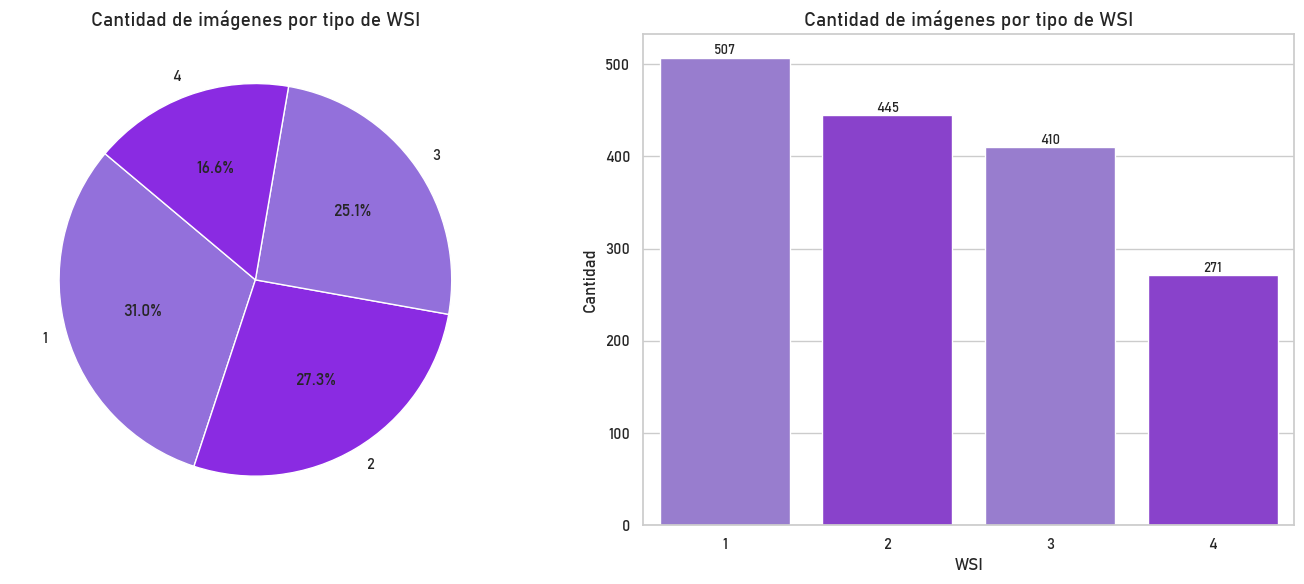

In [13]:
dataset_counts2 = data_imagenes_teselas['source_wsi'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(dataset_counts2, labels=dataset_counts2.index, autopct='%1.1f%%', startangle=140, colors=colores_morado)
axes[0].set_title('Cantidad de imágenes por tipo de WSI', fontsize=14)
sns.barplot(x=dataset_counts2.index, y=dataset_counts2.values, ax=axes[1], palette=colores_morado)
axes[1].set_title('Cantidad de imágenes por tipo de WSI', fontsize=14)
axes[1].set_xlabel('WSI', fontsize=12)
axes[1].set_ylabel('Cantidad', fontsize=12)
for i, count in enumerate(dataset_counts2.values):
    axes[1].text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

En este estudio, trabajamos con imágenes WSI (*Whole Slide Images*), que son imágenes digitales de alta resolución obtenidas de muestras de tejido en portaobjetos de microscopio. Aunque se capturaron más WSI, solo consideramos cuatro en este análisis, excluyendo aquellas asignadas al conjunto de datos 3.  

Al observar las gráficas, notamos que las frecuencias de las imágenes por WSI son relativamente similares, sin diferencias extremadamente marcadas. Sin embargo, hay una tendencia clara: la WSI **1** contiene la mayor cantidad de imágenes, seguida por la **2**, y en menor proporción la **3** y la **4**. Esto sugiere que, a medida que aumentó el número de WSI, la cantidad de imágenes extraídas de cada una disminuyó, posiblemente debido a criterios de muestreo o a la disponibilidad de regiones de interés en cada WSI.

In [14]:
data_imagenes_teselas['id'].unique(). shape[0]

1633

**Importante:** Nótese que todas las imágenes tienen un `id` único. 

## **polygons.jsonl: Máscaras de segmentación poligonal**

Ahora, exploremos el archivo .json. Este archivo contiene las máscaras de segmentación poligonal para los conjuntos de datos 1 y 2. Incluye tanto máscaras revisadas por expertos como aquellas que no lo han sido. Profundicemos un poco más en esta información.

In [15]:
# Cargar las anotaciones desde el archivo JSONL
with open('polygons.jsonl') as archivo_json:  # Abre el archivo JSONL en modo lectura
    lista_json = list(archivo_json)  # Lee todas las líneas y las almacena en una lista

# Inicializar una lista para almacenar los datos procesados
mascaras = []

# Convertir cada línea de JSON en un diccionario y almacenarlo en la lista
for linea_json in lista_json:
    mascaras.append(json.loads(linea_json))  # Convierte la línea JSON en un diccionario y lo agrega a la lista

# Ver el total de filas
total_filas = len(mascaras)
print(f"Total de filas: {total_filas}")

Total de filas: 1633


Observamos que el total de filas (máscaras de segmentación) es de 1633, coincidiendo con el número obtenido previamente al filtrar las teselas para los conjuntos de datos 1 y 2. Esta coincidencia es crucial para poder aplicar posteriormente los modelos correspondientes.

Veamos un ejemplo de ¿Cómo se ve una fila en cada línea del archivo JSON

In [16]:
print("Ejemplo de máscara:", mascaras[:1])  

Ejemplo de máscara: [{'id': '0006ff2aa7cd', 'annotations': [{'type': 'glomerulus', 'coordinates': [[[167, 249], [166, 249], [165, 249], [164, 249], [163, 249], [162, 249], [161, 249], [160, 249], [159, 249], [158, 249], [157, 249], [156, 249], [155, 249], [154, 249], [153, 249], [152, 249], [151, 249], [150, 249], [149, 249], [148, 249], [147, 249], [146, 249], [145, 249], [144, 249], [143, 249], [142, 249], [141, 249], [140, 249], [139, 249], [138, 249], [137, 249], [136, 249], [135, 249], [134, 249], [133, 249], [132, 249], [131, 249], [130, 249], [129, 249], [128, 249], [127, 249], [126, 249], [125, 249], [124, 249], [123, 249], [122, 249], [122, 248], [121, 248], [120, 248], [119, 248], [118, 248], [117, 248], [117, 247], [116, 247], [115, 247], [115, 246], [114, 246], [113, 246], [112, 246], [111, 246], [110, 246], [110, 245], [109, 245], [108, 245], [107, 245], [106, 245], [106, 244], [105, 244], [105, 243], [104, 243], [103, 243], [103, 242], [102, 242], [101, 242], [100, 242], 

Al analizar la primera línea de la máscara asociada a una imagen, observamos que esta incluye el **ID de la imagen**, lo que facilita su vinculación y visualización posterior. Además, contiene las **anotaciones** que identifican y delimitan las regiones de interés, permitiendo dibujar los **píxeles segmentados** y resaltar las **estructuras específicas** dentro del tejido. Este proceso es particularmente interesante, ya que posibilita una mejor interpretación de las características morfológicas y patológicas presentes en la muestra, contribuyendo así a un análisis más preciso y detallado.

In [17]:
data_info_mascaras = pd.DataFrame(mascaras)
data_info_mascaras.head()

,id,annotations
0,0006ff2aa7cd,"[{'type': 'glomerulus', 'coordinates': [[[167,..."
1,00168d1b7522,"[{'type': 'glomerulus', 'coordinates': [[[511,..."
2,0033bbc76b6b,"[{'type': 'blood_vessel', 'coordinates': [[[16..."
3,003504460b3a,"[{'type': 'blood_vessel', 'coordinates': [[[40..."
4,004daf1cbe75,"[{'type': 'blood_vessel', 'coordinates': [[[14..."


In [18]:
data_info_mascaras["id"].unique(). shape[0]

1633

**Importante:** Nótese que todas las máscaras tienen un `id` único. Esto coincide con la cantidad de imágenes de teselas que se obtuvieron de los WSI.

## **Unión de tablas**

Dado que tanto las máscaras como las imágenes tienen la misma cantidad de **ID únicos (1633)**, podemos realizar un **merge** entre las tablas **data_info_mascaras** y **data_info_teselas**. Esto nos permitirá verificar si los ID coinciden correctamente y asegurarnos de que cada imagen tiene su máscara correspondiente. De esta manera, podremos evaluar la integridad de los datos y confirmar que todas las imágenes cuentan con su respectiva segmentación.

In [19]:
data_imagenes = pd.merge(data_info_mascaras, data_imagenes_teselas, on="id", how="inner")
data_imagenes.head()

,id,annotations,source_wsi,dataset,i,j
0,0006ff2aa7cd,"[{'type': 'glomerulus', 'coordinates': [[[167,...",2,2,16896,16420
1,00168d1b7522,"[{'type': 'glomerulus', 'coordinates': [[[511,...",2,2,14848,14884
2,0033bbc76b6b,"[{'type': 'blood_vessel', 'coordinates': [[[16...",1,1,10240,43008
3,003504460b3a,"[{'type': 'blood_vessel', 'coordinates': [[[40...",3,2,8192,11776
4,004daf1cbe75,"[{'type': 'blood_vessel', 'coordinates': [[[14...",3,2,6144,11264


In [20]:
data_imagenes["id"].unique(). shape[0]

1633

En efecto, sí se cumple que cada imagen tenga su máscara asociada y coincidan.

## **Visualización de imágenes**

Veamos las primeras **5** imágenes del conjunto de datos

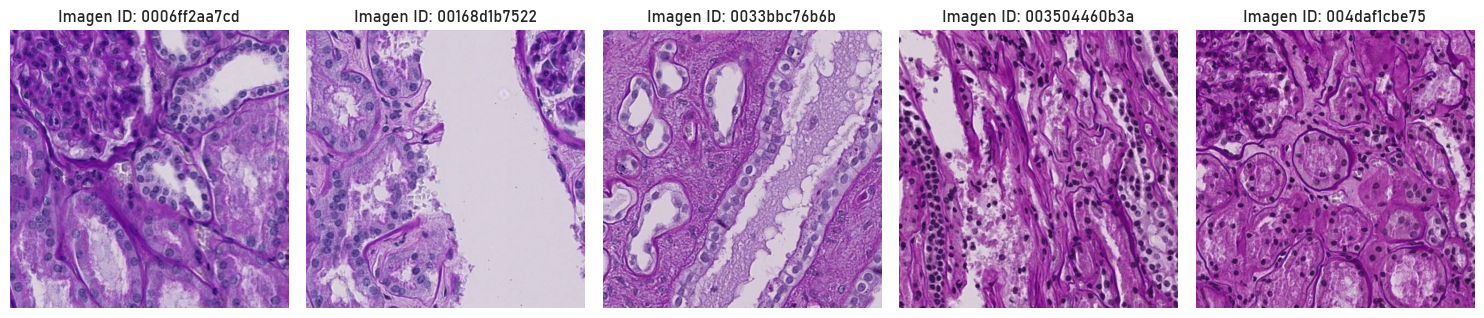

In [22]:
mostrar_imagenes(data_imagenes, ruta_imagenes, 5)

La visualización muestra las **primeras 5 imágenes** del conjunto de datos de entrenamiento, identificadas por su **ID único**. Se trata de imágenes histológicas donde se pueden apreciar diferentes estructuras celulares y tisulares.

Ahora veamos la máscara de la primera imagen.

In [23]:
graficar_imagen_mascara(mascaras[0])

La estructura de las máscaras resulta especialmente interesante, ya que no solo permiten visualizar las **anotaciones**, sino que también facilitan la superposición con la **imagen original**. Esta forma de representación gráfica es clave para analizar y comprender mejor las regiones de interés, permitiendo una interpretación más clara de las segmentaciones y su correspondencia con la imagen real.

### **Métodos para graficas imágenes y máscaras**

In [24]:
# Crear máscaras vacías para cada tipo de anotación
def crear_mascaras_vacias(ANCHO_IMAGEN=512, ALTO_IMAGEN=512, NUMERO_CANAL=3):
    """Genera máscaras vacías para cada tipo de estructura anatómica anotada en la imagen."""
    mascara_glomerulo = np.zeros((ANCHO_IMAGEN, ALTO_IMAGEN, NUMERO_CANAL), dtype=np.uint8)
    mascara_vaso_sanguineo = np.zeros((ANCHO_IMAGEN, ALTO_IMAGEN, NUMERO_CANAL), dtype=np.uint8)
    mascara_indefinida = np.zeros((ANCHO_IMAGEN, ALTO_IMAGEN, NUMERO_CANAL), dtype=np.uint8)
    return {'glomerulus': mascara_glomerulo, 'blood_vessel': mascara_vaso_sanguineo, 'unsure': mascara_indefinida}

# Rellenar las máscaras con las anotaciones de la imagen
def rellenar_mascaras_con_anotaciones(id_imagen, mascaras):
    """Dibuja las regiones anotadas en las máscaras correspondientes usando coordenadas predefinidas."""
    anotaciones = data_imagenes.loc[data_imagenes["id"] == id_imagen, 'annotations'].iloc[0]
    
    for anotacion in anotaciones:
        tipo_anotacion = anotacion['type']  # Tipo de estructura anotada
        coordenadas = anotacion['coordinates']  # Lista de coordenadas del polígono anotado
        color = np.random.randint(0, 255, size=3).tolist()  # Genera un color aleatorio para cada instancia
        
        # Rellena la región anotada en la máscara correspondiente
        cv2.fillPoly(mascaras[tipo_anotacion], [np.array(coordenadas)], color)
    
    return mascaras

In [25]:
# Graficar las máscaras generadas
def graficar_mascaras(id_imagen):
    """Muestra las máscaras generadas para cada tipo de anotación."""
    mascaras_vacias = crear_mascaras_vacias()
    mascaras = rellenar_mascaras_con_anotaciones(id_imagen, mascaras_vacias)
    
    fig, axs = plt.subplots(1, 3, figsize=(8, 8))
    axs[0].imshow(mascaras['glomerulus'], cmap='gray')
    axs[0].set_title('Máscara Glomérulo')

    axs[1].imshow(mascaras['blood_vessel'], cmap='gray')
    axs[1].set_title('Máscara Vaso Sanguíneo')

    axs[2].imshow(mascaras['unsure'], cmap='gray')
    axs[2].set_title('Máscara Indefinida')
    
    plt.tight_layout()
    plt.show()

# Combinar todas las máscaras en una sola imagen
def combinar_mascaras(mascaras):
    """Concatena todas las máscaras en un solo array de imágenes para visualización."""
    mascara_glomerulo = mascaras['glomerulus']
    mascara_vaso_sanguineo = mascaras['blood_vessel']
    mascara_indefinida = mascaras['unsure']
    
    # Se concatenan a lo largo del tercer eje (canal de color)
    imagen_combinada = np.concatenate([mascara_glomerulo, mascara_vaso_sanguineo, mascara_indefinida], axis=2)
    return imagen_combinada


In [26]:
# Obtener una imagen a partir de su ID
def obtener_imagen(id_imagen):
    """Carga la imagen original desde la ruta especificada."""
    ruta_imagen = ruta_imagenes + id_imagen + ".tif"
    imagen = imageio.v2.imread(ruta_imagen)
    return imagen


In [27]:
# Obtener imagen con máscaras superpuestas
def obtener_imagen_con_mascaras_superpuestas(id_imagen):
    """Superpone las máscaras sobre la imagen original para visualización."""
    anotaciones = data_imagenes.loc[data_imagenes["id"] == id_imagen, 'annotations'].iloc[0]
    img = obtener_imagen(id_imagen)
    
    # Definir colores específicos para cada tipo de anotación
    ROJO = (255, 0, 0)         # Para vasos sanguíneos
    VERDE_OSCURO = (0, 255, 0) # Para glomérulos
    AZUL_OSCURO = (0, 0, 255)  # Para áreas indefinidas
    
    mapa_colores = {'blood_vessel': ROJO, 'glomerulus': VERDE_OSCURO, 'unsure': AZUL_OSCURO}
    conteo_instancias = {'blood_vessel': 0, 'glomerulus': 0, 'unsure': 0}
    
    for anotacion in anotaciones:
        color = mapa_colores[anotacion['type']]
        conteo_instancias[anotacion['type']] += 1
        coords = np.array(anotacion['coordinates'])
        
        # Dibuja los contornos de las anotaciones sobre la imagen
        cv2.polylines(img, coords, True, color, 3)
    
    return img, conteo_instancias

# Dibujar la imagen con la superposición de máscaras
def dibujar_mascaras_sobre_imagen(id_imagen):
    """Muestra la imagen con las máscaras superpuestas y cuenta las instancias de cada anotación."""
    img, conteo_instancias = obtener_imagen_con_mascaras_superpuestas(id_imagen)
    
    print(f"Vasos Sanguíneos Conteo: {conteo_instancias['blood_vessel']}")
    print(f"Glomérulos Conteo: {conteo_instancias['glomerulus']}")
    print(f"Indefinido Conteo: {conteo_instancias['unsure']}")

In [28]:

def graficar_mascaras_y_imagen_original(id_imagen):
    """Dibuja la imagen original junto con las máscaras generadas y su superposición."""
    mascaras_vacias = crear_mascaras_vacias()
    mascaras = rellenar_mascaras_con_anotaciones(id_imagen, mascaras_vacias)
    imagen = obtener_imagen(id_imagen)
    imagen_superpuesta, _ = obtener_imagen_con_mascaras_superpuestas(id_imagen)
    
    fig, axs = plt.subplots(1, 5, figsize=(16, 16))
    axs[0].imshow(mascaras['glomerulus'], cmap='gray')
    axs[0].set_title('Máscara Glomérulo')

    axs[1].imshow(mascaras['blood_vessel'], cmap='gray')
    axs[1].set_title('Máscara Vaso Sanguíneo')

    axs[2].imshow(mascaras['unsure'], cmap='gray')
    axs[2].set_title('Máscara Indefinida')
    
    axs[3].imshow(imagen)
    axs[3].set_title('Imagen Original')
    
    axs[4].imshow(imagen_superpuesta)
    axs[4].set_title("Máscara sobre la Imagen")
    
    # Quitar los ejes para mejor visualización
    for ax in axs.flat:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()


### **Ver imágenes y máscaras**

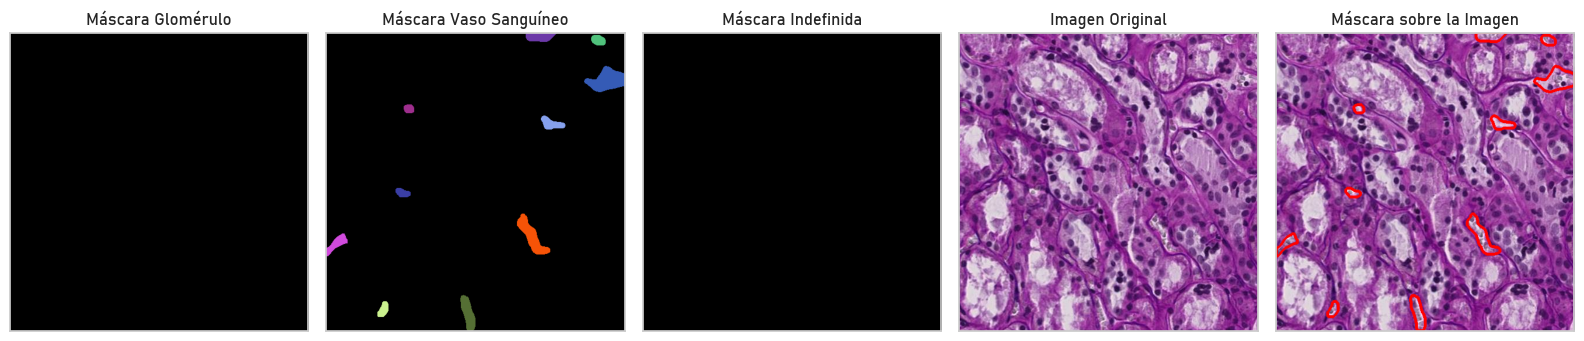

In [29]:
graficar_mascaras_y_imagen_original(imagen_pruebas)

In [30]:
dibujar_mascaras_sobre_imagen(imagen_pruebas)

Vasos Sanguíneos Conteo: 10
Glomérulos Conteo: 0
Indefinido Conteo: 0


Podemos notar que en las imágenes hay un total de 8 máscaras asociadas a la estructura de vasos sanguíneos (blood vessels) y 1 máscara correspondiente a un glomérulo. No se identificaron máscaras en la categoría indefinida. En la visualización, las máscaras segmentadas se muestran en distintos colores en los primeros paneles, mientras que en la última imagen se superponen sobre la muestra original, donde los vasos sanguíneos están delineados en rojo y el glomérulo en verde. Esto indica que el proceso de segmentación está diferenciando correctamente estas estructuras dentro del tejido.

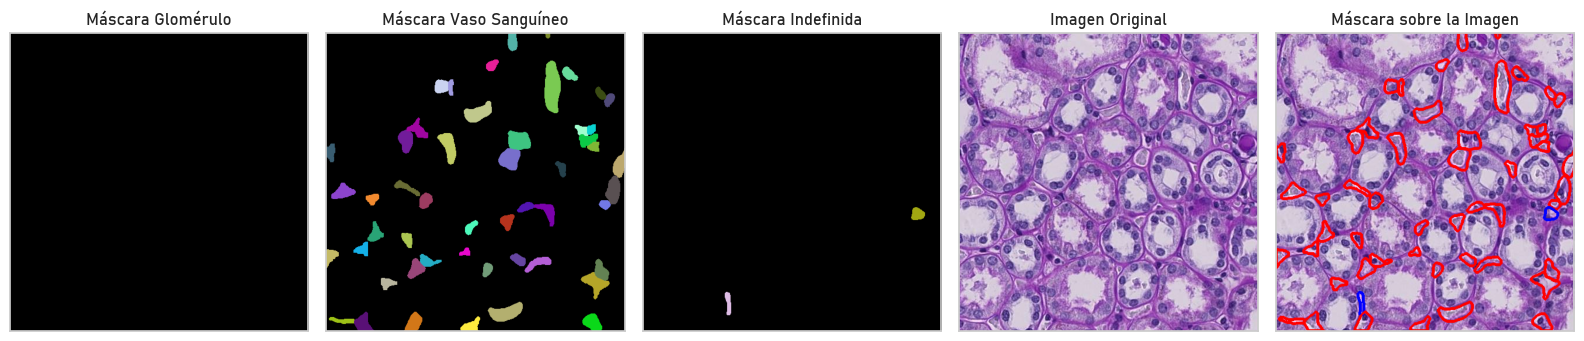

In [31]:
graficar_mascaras_y_imagen_original(imagen_pruebas2)


In [32]:
dibujar_mascaras_sobre_imagen(imagen_pruebas2)

Vasos Sanguíneos Conteo: 51
Glomérulos Conteo: 0
Indefinido Conteo: 2


Podemos notar que en las imágenes hay un total de 51 máscaras asociadas a vasos sanguíneos, mientras que no se identificaron glomérulos y se detectaron 2 regiones dentro de la categoría indefinida. En la visualización, los vasos sanguíneos segmentados se muestran en distintos colores en la segunda imagen, mientras que en la última imagen las máscaras se superponen sobre la muestra original, con los vasos sanguíneos delineados en rojo y las regiones indefinidas en azul. Esto indica que el modelo ha identificado una gran cantidad de estructuras vasculares en la muestra, pero no ha detectado glomérulos en esta región específica del tejido.

Ahora guardemos las máscaras para el posterior análisis y modelado.

In [33]:
def guardar_todas_las_mascaras(carpeta_salida="mascaras_guardadas"):
    """Genera y guarda las máscaras coloreadas para todas las imágenes en data_imagenes en formato TIF."""
    
    if not os.path.exists(carpeta_salida):
        os.makedirs(carpeta_salida)
    
    for id_imagen in data_imagenes["id"]:
        ANCHO_IMAGEN, ALTO_IMAGEN = 512, 512  
        mascara_coloreada = np.zeros((ALTO_IMAGEN, ANCHO_IMAGEN, 3), dtype=np.uint8)
        
        anotaciones = data_imagenes.loc[data_imagenes["id"] == id_imagen, 'annotations'].iloc[0]
        
        colores = {'blood_vessel': (255, 0, 0),  # Rojo
                   'glomerulus': (0, 255, 0),    # Verde
                   'unsure': (0, 0, 255)}        # Azul
        
        
        for anotacion in anotaciones:
            tipo = anotacion['type']
            coords = np.array(anotacion['coordinates'], np.int32)  
            
            if tipo in colores:  
                cv2.fillPoly(mascara_coloreada, [coords], colores[tipo])  
        ruta_guardado = os.path.join(carpeta_salida, f"{id_imagen}_mascara.tif")
        imageio.imwrite(ruta_guardado, mascara_coloreada, format='TIF')
    

guardar_todas_las_mascaras()


## **Análisis descriptivo de imágenes**

En esta sección veremos un poco más sobre cómo están distribuidas las clases, los píxeles y colores del conjunto de imágenes.

`````{admonition} ¿Qué son los píxeles?
:class: tip
Los píxeles son los puntos que forman una imagen digital en una pantalla. Son la unidad mínima de información gráfica que se muestra en una computadora. 
`````

### **Distribución de anotaciones**

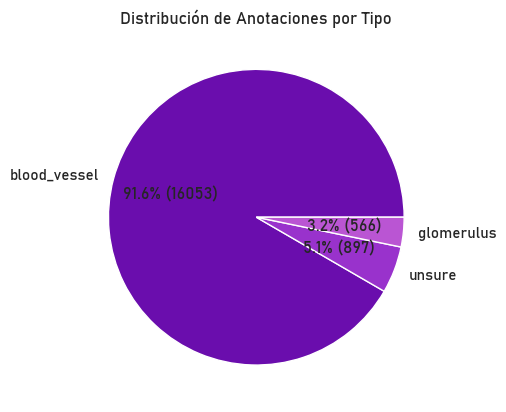

In [34]:
# Expandir la columna 'annotations' para obtener cada anotación individualmente
annotations_list = data_imagenes['annotations'].explode()

# Extraer el campo 'type' de cada diccionario dentro de las anotaciones
types = annotations_list.apply(lambda x: x['type'])

# Contar la cantidad de ocurrencias de cada tipo de anotación
type_counts = types.value_counts()

colores_morados = ["#6A0DAD",  "#9932CC", "#BA55D3"]

plt.pie(type_counts, 
        labels=type_counts.index, 
        autopct=lambda pct: f'{pct:.1f}% ({int(pct * sum(type_counts)/100)})', 
        colors=colores_morados)

plt.title("Distribución de Anotaciones por Tipo")
plt.show()
plt.close()


### **Tamaño de las imágenes**


`````{admonition} Tamaño de las imágenes
:class: tip
El tamaño de una imagen en píxeles se expresa con dos números: el número de columnas de píxeles (ancho) y el número de filas de píxeles (alto). (Tamaño = ancho * alto)
`````

El conjunto de imágenes proporcionado tiene un tamaño uniforme de **512x512 píxeles**, ya que fueron previamente procesadas. Esto se debe a que cada imagen es un fragmento extraído de una **WSI (Whole Slide Image)**, que ha sido segmentada en porciones más pequeñas para facilitar su análisis y procesamiento.

In [35]:
imagen = obtener_imagen(imagen_pruebas)
imagen.shape

(512, 512, 3)

En efecto, las imágenes del conjunto de datos tienen un tamaño de 512x512 píxeles y cuentan con 3 canales de color, lo que indica que son imágenes en formato RGB. Este formato es estándar en procesamiento de imágenes médicas y permite realizar análisis detallados de la estructura y composición del tejido.

### **Mapa de intensidad de píxeles**

Para comprender mejor la distribución de los valores de los píxeles en nuestras imágenes, visualizaremos un mapa de intensidad. Este tipo de gráfico nos permite identificar patrones en la luminosidad y contraste, resaltando áreas de mayor y menor intensidad en una imagen. Convertiremos la imagen a escala de grises si es necesario y aplicaremos un heatmap para representar la variación en los niveles de intensidad de los píxeles. Esto es útil para detectar características relevantes en el procesamiento y análisis de imágenes.

`````{admonition} Colores en una imagen
:class: tip
En una imagen en escala de grises:  

- Si el valor del píxel se acerca a 0, significa que es negro (más oscuro).  
- Si el valor del píxel se acerca a 255, significa que es blanco (más claro).  

En imágenes en color (RGB), cada canal (Rojo, Verde, Azul) sigue la misma lógica:  
- 0 en un canal = ausencia de ese color.  
- 255 en un canal = intensidad máxima de ese color.
`````

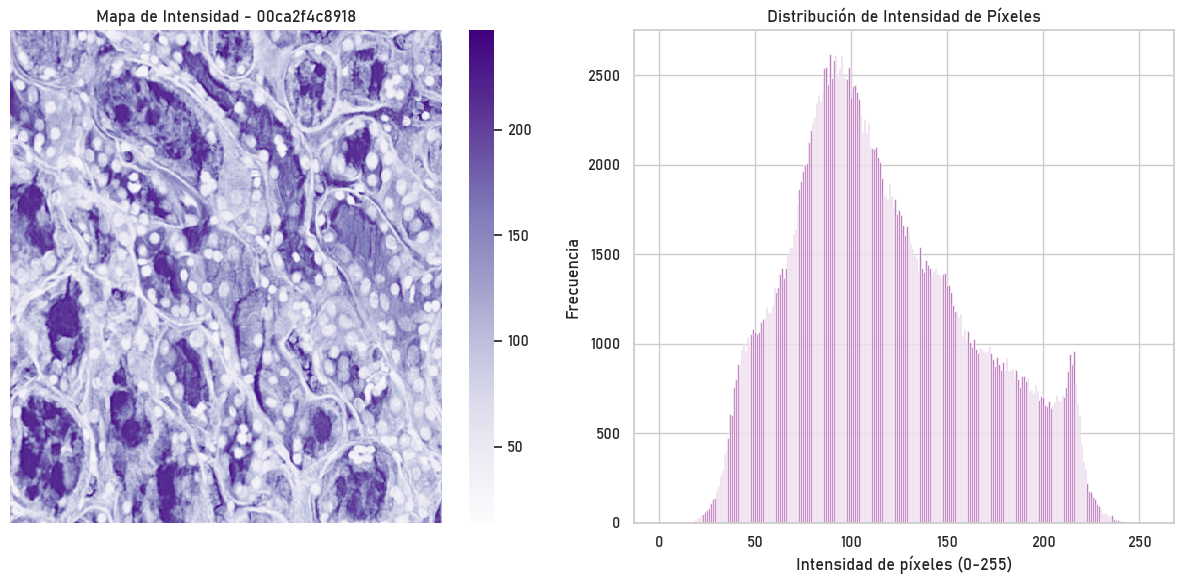

In [36]:
def generar_mapa_intensidad(id_imagen, ruta_imagenes):
    ruta_imagen = os.path.join(ruta_imagenes, id_imagen + ".tif")
    imagen = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

    if imagen is None:
        print(f"No se pudo cargar la imagen {id_imagen}")
        return

    histograma, bins = np.histogram(imagen.ravel(), bins=256, range=[0, 256])

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Mostrar el mapa de intensidad
    sns.heatmap(imagen, cmap="Purples", cbar=True, ax=ax[0])
    ax[0].set_title(f"Mapa de Intensidad - {id_imagen}")
    ax[0].axis("off")

    # Mostrar el histograma de intensidades
    ax[1].bar(range(256), histograma, color='purple', alpha=0.7)
    ax[1].set_title("Distribución de Intensidad de Píxeles")
    ax[1].set_xlabel("Intensidad de píxeles (0-255)")
    ax[1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

generar_mapa_intensidad(imagen_pruebas, ruta_imagenes)


La imagen presenta un mapa de intensidad de píxeles y su correspondiente histograma para la imagen identificada como "0006ff2aa7cd". En el mapa de intensidad, los tonos más oscuros representan regiones de mayor concentración de píxeles de baja intensidad, mientras que los tonos más claros indican áreas con valores más altos. A la derecha, el histograma muestra la distribución de los niveles de intensidad en un rango de 0 a 255, con una mayor frecuencia de píxeles en intensidades intermedias (alrededor de 100-150), lo que sugiere una predominancia de tonos grises en la imagen. Este análisis es útil para evaluar el contraste y la estructura de la imagen en estudios de diagnóstico o procesamiento de imágenes médicas.

### **Histograma de escala de grises**


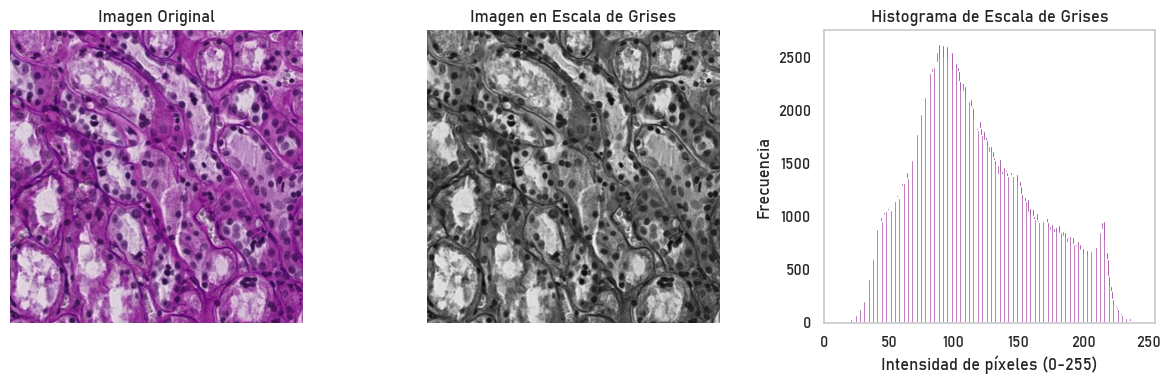

In [37]:

def mostrar_histograma_escala_grises(id_imagen, ruta_imagenes):

    imagen = imageio.imread(os.path.join(ruta_imagenes, id_imagen + ".tif"))
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
    histograma, bins = np.histogram(imagen_gris.ravel(), bins=256, range=[0,256])
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    
    # Imagen original
    axs[0].imshow(imagen)
    axs[0].set_title("Imagen Original")
    axs[0].axis("off")

    # Imagen en escala de grises
    axs[1].imshow(imagen_gris, cmap="gray")
    axs[1].set_title("Imagen en Escala de Grises")
    axs[1].axis("off")

    # Histograma de intensidades con barras más gruesas
    axs[2].bar(range(256), histograma, color="purple", alpha=1.0, width=1.5)
    axs[2].set_xlim([0, 255])  # Asegura que cubra todo el rango de intensidades
    axs[2].set_xlabel("Intensidad de píxeles (0-255)")
    axs[2].set_ylabel("Frecuencia")
    axs[2].set_title("Histograma de Escala de Grises")
    axs[2].grid(False)  # Desactiva la cuadrícula para más claridad

    plt.tight_layout()
    plt.show()


mostrar_histograma_escala_grises(imagen_pruebas, ruta_imagenes)


La imagen muestra un análisis de intensidad de píxeles en una muestra de tejido. A la izquierda, la imagen original conserva su coloración característica, mientras que en el centro se presenta su versión en escala de grises, resaltando contrastes estructurales. A la derecha, el histograma de escala de grises representa la distribución de intensidades de píxeles (0-255), con un pico en valores intermedios, indicando que predominan tonos grises de intensidad media. La alta frecuencia de ciertos valores sugiere regiones con estructuras bien definidas dentro del tejido, lo que puede ser útil para su segmentación.

### **Distribución de canales de color**

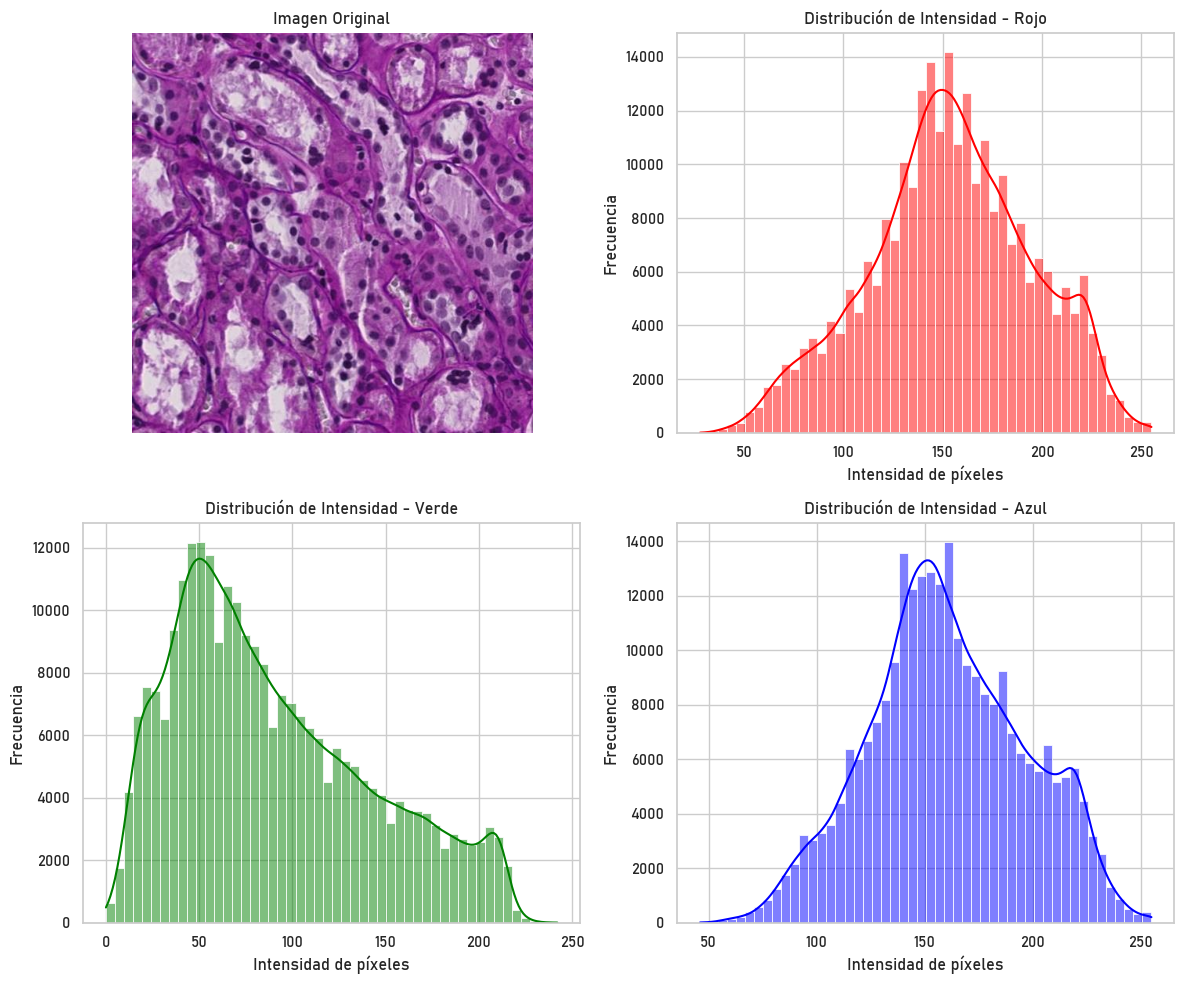

In [38]:

ruta_imagen = os.path.join(ruta_imagenes.strip(), imagen_pruebas + ".tif")

imagen = cv2.imread(ruta_imagen)
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB) 
R, G, B = imagen[:, :, 0], imagen[:, :, 1], imagen[:, :, 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Mostrar la imagen original
axes[0, 0].imshow(imagen)
axes[0, 0].axis("off")
axes[0, 0].set_title("Imagen Original")

# Crear los histogramas de cada canal
sns.histplot(R.flatten(), color="red", ax=axes[0, 1], kde=True, bins=50)
axes[0, 1].set_title("Distribución de Intensidad - Rojo")
axes[0, 1].set_xlabel("Intensidad de píxeles")
axes[0, 1].set_ylabel("Frecuencia")

sns.histplot(G.flatten(), color="green", ax=axes[1, 0], kde=True, bins=50)
axes[1, 0].set_title("Distribución de Intensidad - Verde")
axes[1, 0].set_xlabel("Intensidad de píxeles")
axes[1, 0].set_ylabel("Frecuencia")

sns.histplot(B.flatten(), color="blue", ax=axes[1, 1], kde=True, bins=50)
axes[1, 1].set_title("Distribución de Intensidad - Azul")
axes[1, 1].set_xlabel("Intensidad de píxeles")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()  
plt.show()



La imagen original en la esquina superior izquierda muestra una micrografía teñida predominantemente en tonos morados. Los histogramas de los canales de color rojo, verde y azul muestran la distribución de intensidad de píxeles en cada componente. Se observa que el canal azul tiene valores más altos de intensidad en comparación con los otros canales, lo que indica una predominancia de este color en la imagen. El canal rojo tiene una distribución bimodal con un pico principal alrededor de 150 y otro menor cerca de 200, mientras que el canal verde muestra un comportamiento similar pero con su pico principal más desplazado hacia la izquierda. Estas distribuciones reflejan la composición cromática de la imagen y pueden ser útiles en análisis de segmentación.

### **Filtrado de imágenes con OpenCV**

A continuación se hará un filtrado de imágenes.

:::{admonition} ¿Qué son los filtros en imágenes?
:class: tip
Los filtros en imágenes son operaciones matemáticas aplicadas sobre los píxeles para modificar ciertas características visuales. Estos pueden utilizarse para mejorar el contraste, eliminar ruido o detectar bordes. En este caso, se emplean filtros de suavizado para reducir el ruido presente en la imagen original.
:::

::: {admonition} Importancia del Filtrado de Imágenes
:class: tip
El filtrado de imágenes es un proceso fundamental en la visión por computadora, ya que permite mejorar la calidad de las imágenes eliminando ruido, resaltando características importantes y suavizando detalles no deseados.
:::



::: {note} **Tipos de filtros aplicados**

- **Filtro de Media (cv2.blur)**: Calcula el promedio de los valores de píxeles en una vecindad definida por una ventana (en este caso, de 3x3). Suaviza la imagen pero puede afectar los bordes.
- **Filtro de Mediana (cv2.medianBlur)**: Sustituye el valor de cada píxel por la mediana de los valores en su vecindad. Es especialmente útil para eliminar ruido impulsivo o "ruido sal y pimienta" (píxeles blancos (sal) y píxeles negros (pimienta))
- **Filtro Gaussiano (cv2.GaussianBlur)**: Aplica un suavizado utilizando una función gaussiana, lo que genera un efecto más natural y mantiene mejor los bordes en comparación con el filtro de media.
:::

In [39]:
def aplicar_filtros_y_visualizar(imagen):
    # Aplicación de filtros
    meanimg = cv2.blur(imagen, (3, 3))  # Filtro de media
    medianimg = cv2.medianBlur(imagen, 3)  # Filtro de mediana
    gaussianimg = cv2.GaussianBlur(imagen, (3, 3), 0)  # Filtro gaussiano

    # Creación de la figura con subgráficos 2x2
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    # Imagen Original con Ruido
    axs[0, 0].imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    axs[0, 0].set_title('Imagen con Ruido', fontsize=14)
    axs[0, 0].axis('off')

    # Filtro Media
    axs[0, 1].imshow(cv2.cvtColor(meanimg, cv2.COLOR_BGR2RGB))
    axs[0, 1].set_title('Filtro Media', fontsize=14)
    axs[0, 1].axis('off')

    # Filtro Mediana
    axs[1, 0].imshow(cv2.cvtColor(medianimg, cv2.COLOR_BGR2RGB))
    axs[1, 0].set_title('Filtro Mediana', fontsize=14)
    axs[1, 0].axis('off')

    # Filtro Gaussiano
    axs[1, 1].imshow(cv2.cvtColor(gaussianimg, cv2.COLOR_BGR2RGB))
    axs[1, 1].set_title('Filtro Gaussiano', fontsize=14)
    axs[1, 1].axis('off')

    # Ajustar diseño y mostrar
    plt.tight_layout()
    plt.show()

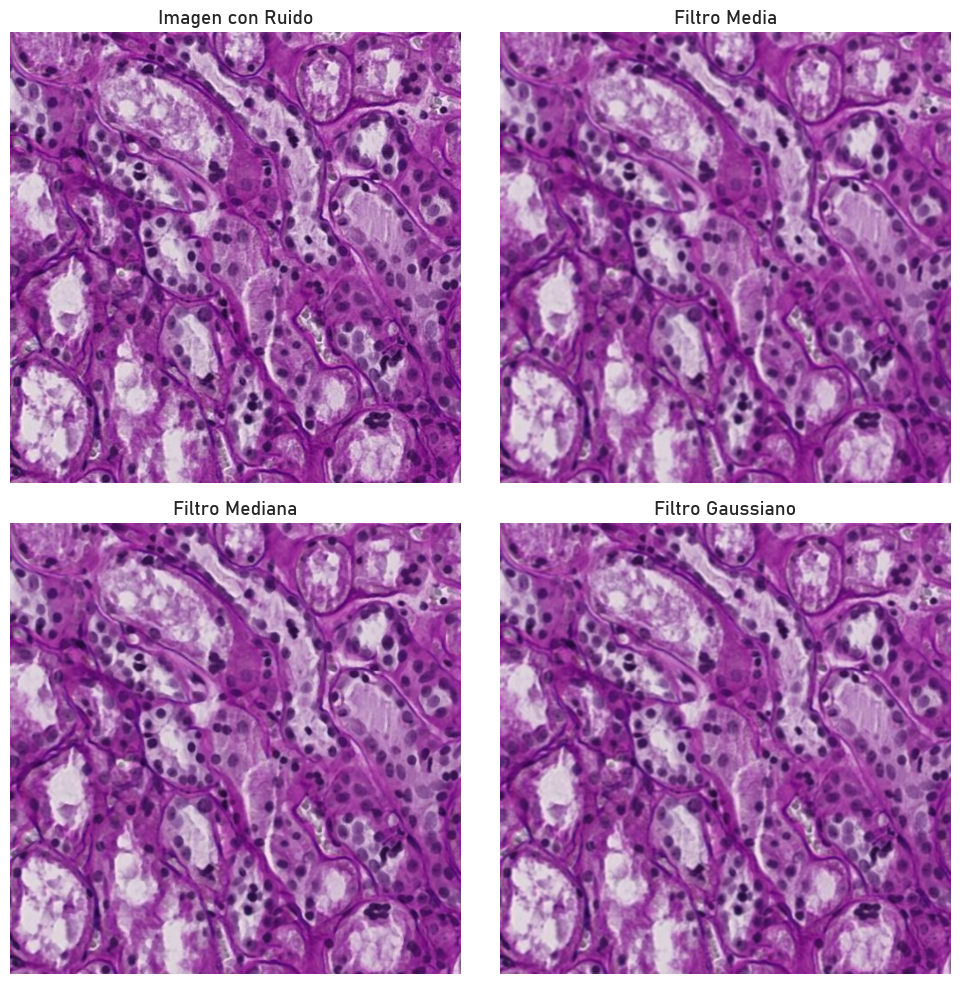

In [40]:
ruta_imagen = os.path.join(ruta_imagenes.strip(), imagen_pruebas + ".tif")
imagen = cv2.imread(ruta_imagen)
aplicar_filtros_y_visualizar(imagen)


La imagen muestra el efecto de diferentes filtros de suavizado aplicados a una imagen microscópica teñida en tonos morados. En la esquina superior izquierda se observa la imagen original con ruido, donde las estructuras celulares presentan detalles nítidos pero también cierta irregularidad en la distribución de los píxeles. En la parte superior derecha, el filtro de media suaviza la imagen al promediar los valores de los píxeles vecinos, reduciendo el ruido pero a costa de difuminar algunos detalles importantes. En la esquina inferior izquierda, el filtro de mediana elimina eficazmente el ruido tipo "sal y pimienta", preservando mejor los bordes y manteniendo la claridad de las estructuras celulares. Finalmente, en la parte inferior derecha, el filtro gaussiano aplica una suavización más natural, logrando un equilibrio entre la reducción de ruido y la conservación de los detalles de la imagen. Estos filtros son útiles en el preprocesamiento de imágenes biomédicas, mejorando su calidad visual y facilitando su análisis.

Veamos la aplicación de los filtros para otra observación.

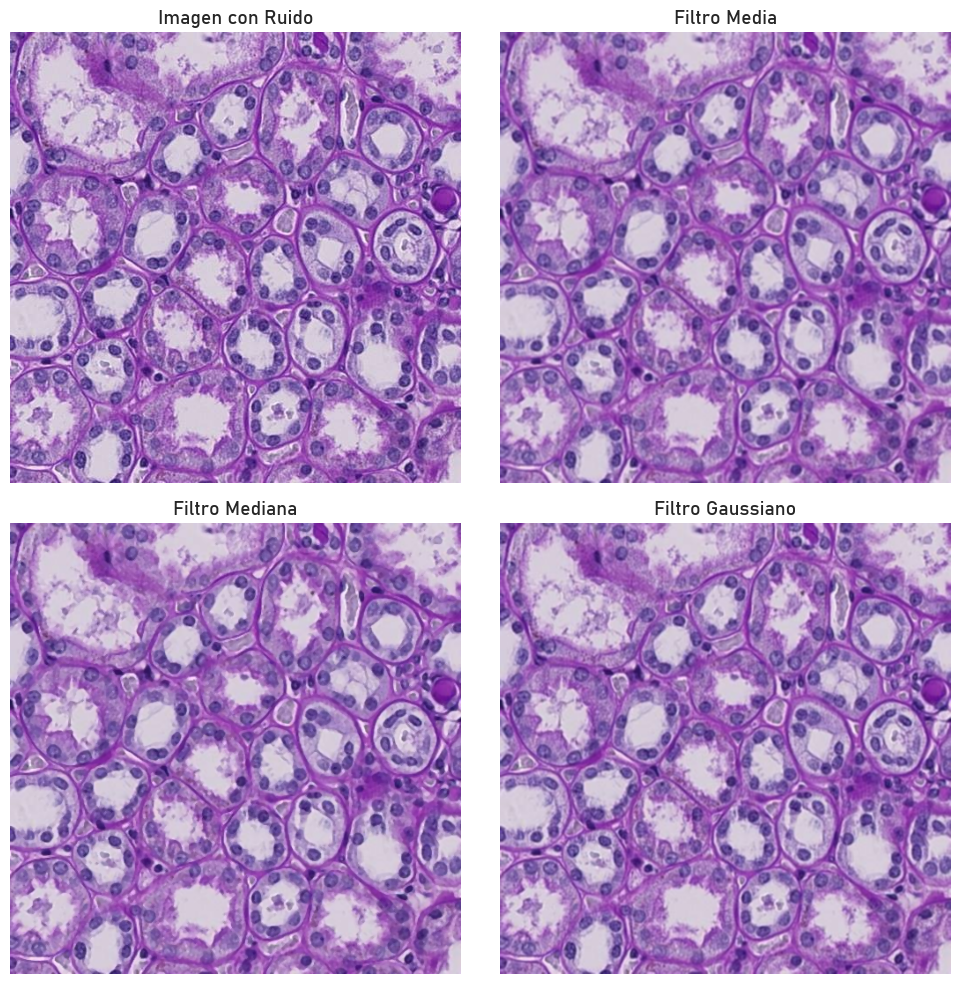

In [41]:
ruta_imagen2 = os.path.join(ruta_imagenes.strip(), imagen_pruebas2 + ".tif")
imagen2 = cv2.imread(ruta_imagen2)
aplicar_filtros_y_visualizar(imagen2)


## **Referencias**
```{bibliography} references.bib
:style: plain
